In [ ]:
print("hello la team DOJO!")

path_to_dataset = './data/dataset'
path_to_cropped = './data/cropped'

In [18]:
import pathlib
path = pathlib.Path(path_to_dataset)
path

PosixPath('data/dataset')

In [19]:
all_images = list(path.glob('**/*.jpg'))
all_images

[PosixPath('data/dataset/other/mangifera_indica/9c88cc8cf8038c107ef3f02d43440f29.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/eacbb23993e1ab4f44ab19c9e6d148c3.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/c469ac4875d7c4618b3b6e1408b35787.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/9dcd76dca90ddfdda893b06b218bca43.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/9f83c87ee72fae6f6ac22b8e0fb8ff88.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/b58b07efca24eefda998feb5a4213612.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/ecd6f0835ce99f441ebadf10ff6a30c6.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/ea622c0eec19eccf3d17258314b35147.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/b71f780bcbb1892a181eb4aa31cffbfa.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/7912e1f2af2d25cf516dfd138ae4df19.jpg'),
 PosixPath('data/dataset/other/eucalyptus_grandis/eaad333471ca2ee46f9c5a76bfdc8552.jpg'),
 PosixPath('

In [ ]:
%pip install Pillow smartcrop

In [ ]:
for image_path in all_images[:2]:
    folder, filename = str(image_path).split('/')[-2:]
    print(folder, filename)

In [ ]:
import smartcrop
import os

from PIL import Image


for image_path in all_images:
    image = Image.open(image_path)
    folder, filename = str(image_path).split('/')[-2:]
    sc = smartcrop.SmartCrop()
    ret = sc.crop(image, 300, 300)
    box = (ret['top_crop']['x'],
           ret['top_crop']['y'],
           ret['top_crop']['width'] + ret['top_crop']['x'],
           ret['top_crop']['height'] + ret['top_crop']['y'])
    img = image.crop(box)
    print(image_path)
    if not os.path.exists(path_to_cropped + folder):
        os.mkdir(path_to_cropped + folder)
    img.save(f"{path_to_cropped}{folder}/{filename}") 

In [ ]:
!pipenv install tensorflow

In [ ]:
!pipenv install numpy

In [ ]:
!pipenv install matplotlib

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

2023-05-30 12:56:55.375224: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import pathlib
data_dir = "./data/result"
data_dir = pathlib.Path(data_dir)
data_dir.absolute()

PosixPath('/Users/ivan/Dev/RF/dojo/dojo-plant/data/result')

In [3]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

304


In [6]:
# Create training set
img_width = 300
img_height = 300
batch_size = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 304 files belonging to 11 classes.
Using 244 files for training.


In [7]:
# Create validation set
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 304 files belonging to 11 classes.
Using 60 files for validation.


In [8]:
class_names = train_ds.class_names
print(class_names)

['acrocarpus_flaxinifolius', 'albizia_coriaria', 'albizia_gummifera', 'albizia_lebbeck', 'albizia_schimperiana', 'allanblackia_stuhlmanii', 'arbustus_unedo', 'arbutus_unedo', 'bambusa_vulgaris', 'bridelia_micrantha', 'castanea_sativa']


In [15]:
len(class_names)

11

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
normalization_layer = layers.Rescaling(1./255)

In [11]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

2023-05-30 12:57:35.714943: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [244]
	 [[{{node Placeholder/_0}}]]
2023-05-30 12:57:35.716359: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [244]
	 [[{{node Placeholder/_4}}]]


0.0 1.0


In [12]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 300, 300, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 300, 300, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 150, 150, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 150, 150, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 75, 75, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 75, 75, 64)        1

In [16]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10


2023-05-30 13:05:40.519392: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [244]
	 [[{{node Placeholder/_0}}]]
2023-05-30 13:05:40.520069: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [244]
	 [[{{node Placeholder/_0}}]]


8/8 [==============================] - ETA: 0s - loss: 3.8476 - accuracy: 0.5082

2023-05-30 13:05:51.455341: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [60]
	 [[{{node Placeholder/_4}}]]
2023-05-30 13:05:51.455809: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [60]
	 [[{{node Placeholder/_0}}]]


8/8 [==============================] - 12s 1s/step - loss: 3.8476 - accuracy: 0.5082 - val_loss: 1.2308 - val_accuracy: 0.7000
Epoch 2/10
8/8 [==============================] - 12s 1s/step - loss: 1.1308 - accuracy: 0.7049 - val_loss: 1.2192 - val_accuracy: 0.7000
Epoch 3/10
8/8 [==============================] - 13s 2s/step - loss: 1.0431 - accuracy: 0.7049 - val_loss: 1.1040 - val_accuracy: 0.7000
Epoch 4/10
8/8 [==============================] - 13s 2s/step - loss: 0.9513 - accuracy: 0.7090 - val_loss: 1.0858 - val_accuracy: 0.7000
Epoch 5/10
8/8 [==============================] - 14s 2s/step - loss: 0.8315 - accuracy: 0.7213 - val_loss: 1.0280 - val_accuracy: 0.7000
Epoch 6/10
8/8 [==============================] - 11s 1s/step - loss: 0.6374 - accuracy: 0.7705 - val_loss: 0.9276 - val_accuracy: 0.7167
Epoch 7/10
8/8 [==============================] - 11s 1s/step - loss: 0.4397 - accuracy: 0.8893 - val_loss: 1.0797 - val_accuracy: 0.7000
Epoch 8/10
8/8 [=============================

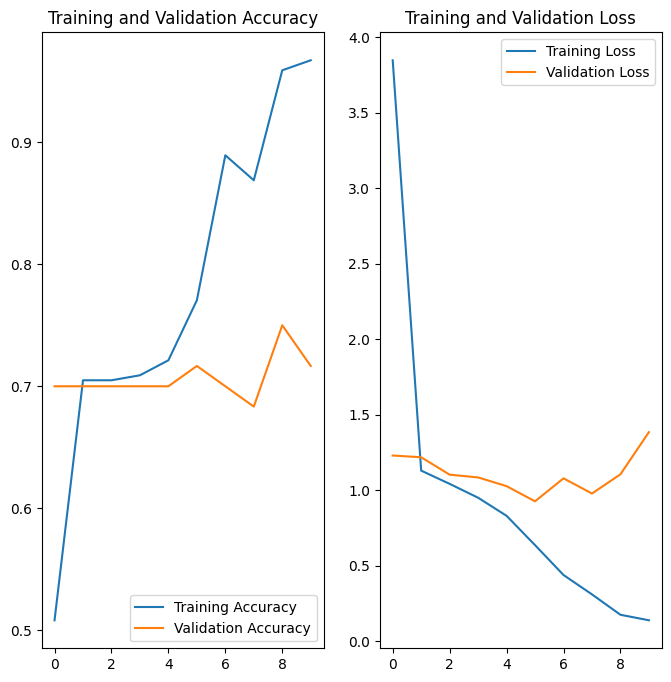

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [19]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

In [23]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

2023-05-30 13:17:36.154238: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [244]
	 [[{{node Placeholder/_0}}]]
2023-05-30 13:17:36.155921: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [244]
	 [[{{node Placeholder/_0}}]]


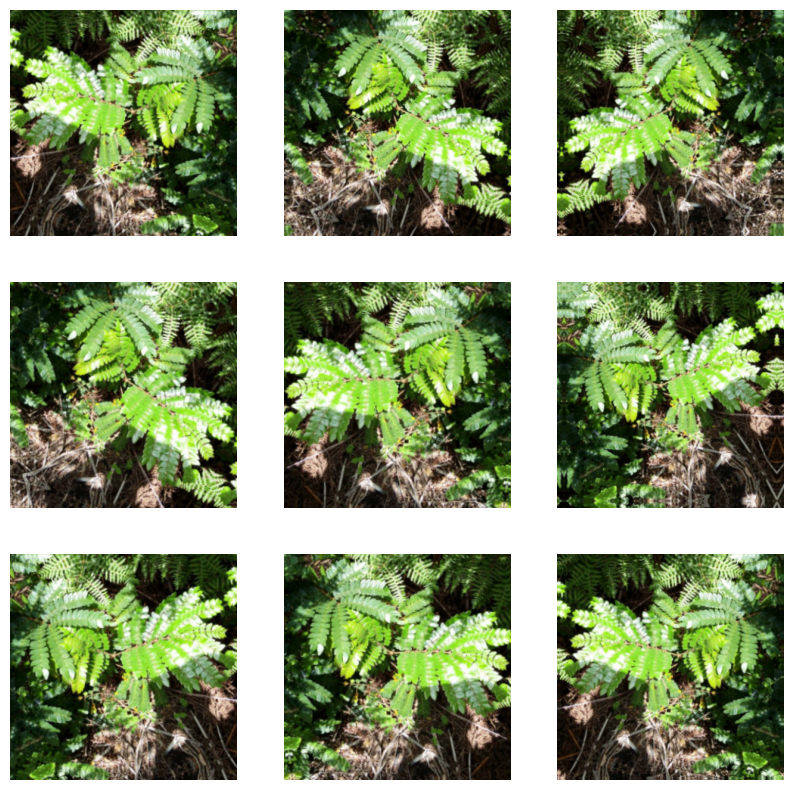

In [20]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [24]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [25]:
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 300, 300, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 300, 300, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 300, 300, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 150, 150, 16)     0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 150, 150, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 75, 75, 32)       0         
 2D)                                                  

In [26]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
8/8 [==============================] - 16s 2s/step - loss: 2.4038 - accuracy: 0.5984 - val_loss: 1.3161 - val_accuracy: 0.7000
Epoch 2/15
8/8 [==============================] - 16s 2s/step - loss: 1.2513 - accuracy: 0.7049 - val_loss: 1.0798 - val_accuracy: 0.7000
Epoch 3/15
8/8 [==============================] - 14s 2s/step - loss: 1.1407 - accuracy: 0.7049 - val_loss: 1.1217 - val_accuracy: 0.7000
Epoch 4/15
8/8 [==============================] - 16s 2s/step - loss: 1.0610 - accuracy: 0.7049 - val_loss: 1.0305 - val_accuracy: 0.7000
Epoch 5/15
8/8 [==============================] - 13s 2s/step - loss: 1.0077 - accuracy: 0.7049 - val_loss: 0.9668 - val_accuracy: 0.7000
Epoch 6/15
8/8 [==============================] - 13s 2s/step - loss: 0.9716 - accuracy: 0.7090 - val_loss: 0.9354 - val_accuracy: 0.7167
Epoch 7/15
8/8 [==============================] - 13s 2s/step - loss: 0.9168 - accuracy: 0.7254 - val_loss: 0.9805 - val_accuracy: 0.7167
Epoch 8/15
8/8 [==================

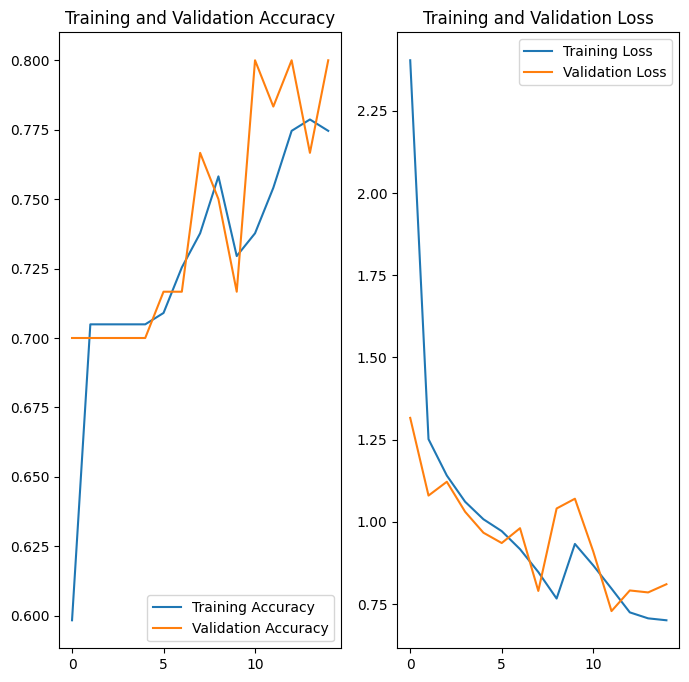

In [27]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [28]:


test_file_url = "file:///Users/ivan/Dev/RF/dojo/dojo-plant/data/test/chene-plant.jpeg"
sunflower_path = tf.keras.utils.get_file('chene', origin=test_file_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

ValueError: unknown url type: './data/test/chene-plant.jpeg'